In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
shopping = pd.read_csv("Shopping_behavior_updated 2.csv")
unemployment = pd.read_csv("Unemployment in America Per US State.csv")

shopping.head(), unemployment.head()

(   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
 0            1   55   Male         Blouse  Clothing                     53   
 1            2   19   Male        Sweater  Clothing                     64   
 2            3   50   Male          Jeans  Clothing                     73   
 3            4   21   Male        Sandals  Footwear                     90   
 4            5   45   Male         Blouse  Clothing                     49   
 
         Location Size      Color  Season  Review Rating Subscription Status  \
 0       Kentucky    L       Gray  Winter            3.1                 Yes   
 1          Maine    L     Maroon  Winter            3.1                 Yes   
 2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
 3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
 4         Oregon    M  Turquoise  Spring            2.7                 Yes   
 
    Shipping Type Discount Applied Promo C

In [ ]:
# Standardize column names
shopping.columns = shopping.columns.str.strip().str.replace(" ", "_").str.lower()
unemployment.columns = unemployment.columns.str.strip().str.replace(" ", "_").str.lower()

shopping.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
# Take only needed columns and calculate average unemployment per state
unemployment_summary = unemployment.groupby("state/area")["percent_(%)_of_labor_force_unemployed_in_state/area"].mean().reset_index()

# Rename columns for merge
unemployment_summary.columns = ["state", "avg_unemployment_rate"]

unemployment_summary.head()

,state,avg_unemployment_rate
0,Alabama,6.847340
1,Alaska,7.721454
2,Arizona,6.218972
3,Arkansas,6.195390
4,California,7.230496


In [ ]:
# Standardize the location column to match state names
shopping["state"] = shopping["location"].str.strip()

# Preview the new column
shopping[["location", "state"]].head()

,location,state
0,Kentucky,Kentucky
1,Maine,Maine
2,Massachusetts,Massachusetts
3,Rhode Island,Rhode Island
4,Oregon,Oregon


In [ ]:
print("Number of unique states in shopping dataset:", shopping["state"].nunique())
print("Number of unique states in unemployment dataset:", unemployment_summary["state"].nunique())

print("\nStates present in shopping but missing in unemployment:")
print(sorted(set(shopping["state"]) - set(unemployment_summary["state"])))


Number of unique states in shopping dataset: 50
Number of unique states in unemployment dataset: 53

States present in shopping but missing in unemployment:
[]


In [ ]:
df = pd.merge(shopping, unemployment_summary, on="state", how="inner")

# Show first rows of the merged dataframe
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,state,avg_unemployment_rate
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Kentucky,6.534397
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Maine,5.631738
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Massachusetts,5.543794
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Rhode Island,6.385993
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Oregon,6.847163


In [ ]:
# eda statistics
df.describe(include="all")

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,state,avg_unemployment_rate
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900.000000
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7,50,NaN
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months,Montana,NaN
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584,96,NaN
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,25.351538,NaN,NaN,NaN,5.836739
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,14.447125,NaN,NaN,NaN,1.066561
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,3.444149
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,5.161259
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,5.901064
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,6.684752


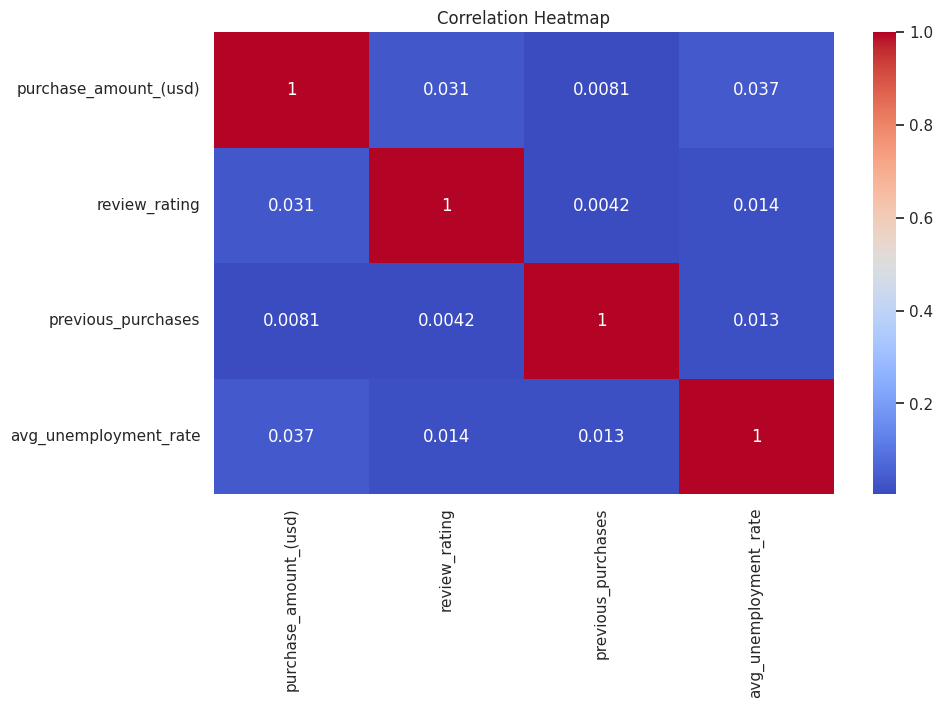

In [ ]:
#correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[["purchase_amount_(usd)",
                "review_rating",
                "previous_purchases",
                "avg_unemployment_rate"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


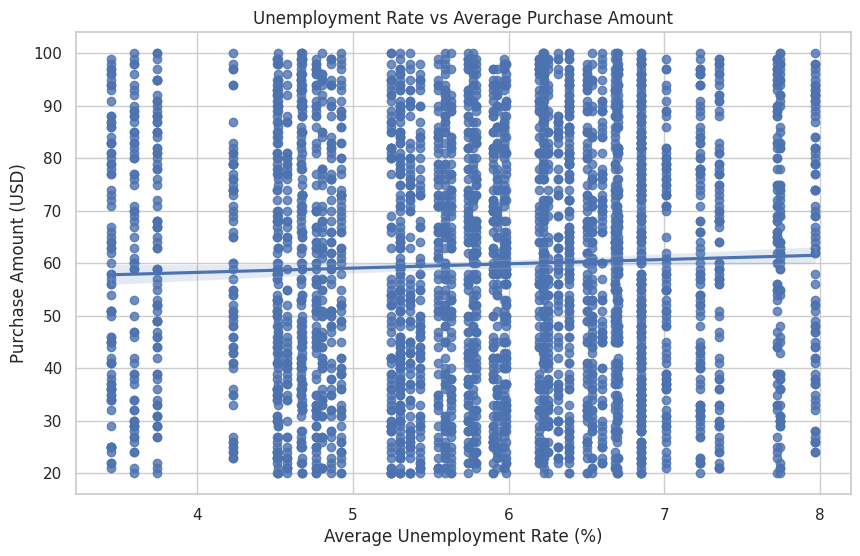

In [ ]:
# H1: Unemployment vs Average Spending

sns.regplot(data=df, x="avg_unemployment_rate", y="purchase_amount_(usd)")
plt.title("Unemployment Rate vs Average Purchase Amount")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Purchase Amount (USD)")
plt.show()

In [ ]:
#H1: Correlation Analysis

from scipy.stats import pearsonr

corr, p_value = pearsonr(df["avg_unemployment_rate"], df["purchase_amount_(usd)"])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.03690268033364804
P-value: 0.021187986230060876


In [ ]:

# H2: Convert frequency_of_purchases to numeric scale


freq_map = {
    "Daily": 30,
    "Weekly": 4,
    "Bi-Weekly": 2,
    "Fortnightly": 2,
    "Monthly": 1,
    "Quarterly": 0.33,
    "Semi-Annually": 0.16,
    "Annually": 0.083
}

df["purchase_frequency_numeric"] = df["frequency_of_purchases"].map(freq_map)

df[["frequency_of_purchases", "purchase_frequency_numeric"]].head()

,frequency_of_purchases,purchase_frequency_numeric
0,Fortnightly,2.000
1,Fortnightly,2.000
2,Weekly,4.000
3,Weekly,4.000
4,Annually,0.083


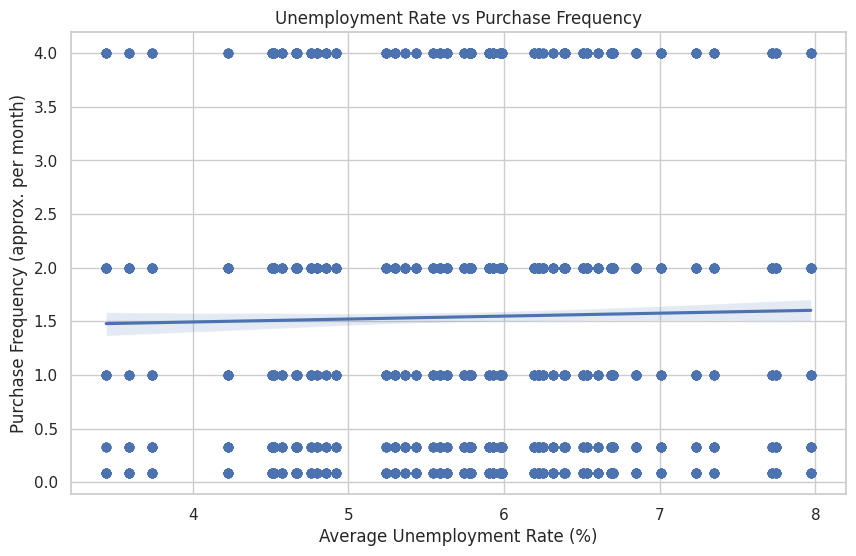

In [ ]:
#Scatter+regression plot

sns.regplot(data=df,
            x="avg_unemployment_rate",
            y="purchase_frequency_numeric")

plt.title("Unemployment Rate vs Purchase Frequency")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Purchase Frequency (approx. per month)")
plt.show()

In [ ]:
#H2: Correlation Analysis

corr2, p2 = pearsonr(df["avg_unemployment_rate"], df["purchase_frequency_numeric"])
print("Correlation:", corr2)
print("P-value:", p2)

Correlation: nan
P-value: nan


In [ ]:
# Remove rows where purchase_frequency_numeric is missing
df_clean = df.dropna(subset=["purchase_frequency_numeric"])

df_clean[["frequency_of_purchases", "purchase_frequency_numeric"]].head()

,frequency_of_purchases,purchase_frequency_numeric
0,Fortnightly,2.000
1,Fortnightly,2.000
2,Weekly,4.000
3,Weekly,4.000
4,Annually,0.083


In [ ]:
#H2: Correlation Analysis Revised

corr2, p2 = pearsonr(df_clean["avg_unemployment_rate"], df_clean["purchase_frequency_numeric"])
print("Correlation:", corr2)
print("P-value:", p2)

Correlation: 0.02212883976347545
P-value: 0.20267809058881464


In [ ]:
# CREATE UNEMPLOYMENT GROUPS FOR CATEGORICAL ANALYSIS


df["unemployment_group"] = pd.qcut(df["avg_unemployment_rate"], q=3, labels=["Low", "Medium", "High"])

df[["state", "avg_unemployment_rate", "unemployment_group"]].head()

,state,avg_unemployment_rate,unemployment_group
0,Kentucky,6.534397,High
1,Maine,5.631738,Medium
2,Massachusetts,5.543794,Medium
3,Rhode Island,6.385993,Medium
4,Oregon,6.847163,High


In [ ]:
# Create discount usage cross-table

pd.crosstab(df["unemployment_group"], df["discount_applied"])

discount_applied,No,Yes
unemployment_group,,
Low,790,585
Medium,703,524
High,730,568


In [ ]:
#H3: Chi-Square Test

from scipy.stats import chi2_contingency

table = pd.crosstab(df["unemployment_group"], df["discount_applied"])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 0.4648296085431841
P-value: 0.7926172740763417


In [ ]:
# H4: Subscription status cross-table

pd.crosstab(df["unemployment_group"], df["subscription_status"])

subscription_status,No,Yes
unemployment_group,,
Low,1010,365
Medium,900,327
High,937,361


In [ ]:
#H4: Chi-Square Test

from scipy.stats import chi2_contingency

table2 = pd.crosstab(df["unemployment_group"], df["subscription_status"])
chi2_sub, p_sub, dof_sub, expected_sub = chi2_contingency(table2)

print("Chi-square statistic:", chi2_sub)
print("P-value:", p_sub)

Chi-square statistic: 0.654465277813975
P-value: 0.7209160104041064
